# Session 4, Notebook 3: OLG Exercise, Closed-Form Savings Rates and Lifecycle Profiles

**Course:** Deep Learning for Solving Dynamic Models - University of Padova, 23-24 September 2026  
**Session:** Day 1, 14:25 - 15:25 - OLG models with DEQNs  
**Slides:** `04_OLG_Models_DEQNs.pdf`  
**Script reference:** §5.2 (the 6-agent analytic Krueger–Kübler OLG); a self-contained warm-up complementing Chapter 5 Exercises 5.1–5.2  
**Notebook role:** exercise  
**Author:** Simon Scheidegger (HEC, University of Lausanne)  


In [1]:
RUN_MODE = "smoke"  # one of: "smoke", "teaching", "production"
SEED = 0

In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(SEED)  # exercise is deterministic but seed for completeness
plt.rcParams['font.size'] = 13
if RUN_MODE == "smoke":
    # Silence figures in CI runs but keep them rendered in the notebook itself.
    plt.rcParams['figure.max_open_warning'] = 0


# Exercise: OLG Savings Rates, Ergodic Prices and Lifecycle Profiles

In this exercise you work with the **analytic six-cohort OLG model** of `04_01_OLG_Analytic_DEQN_persistent.ipynb`, entirely by hand and in NumPy, no neural network. The closed form gives you the policy; the aim is to see what equilibrium it produces.

**Goals (approx. 25 min):**
1. Compute the closed-form savings rates $\beta_h$ for each cohort.
2. Simulate the economy under that policy and read off its **ergodic-mean prices**, prices are endogenous and have to be computed.
3. Trace one cohort's lifecycle at those prices.
4. See how the discount factor $\beta$ shapes the lifecycle *in general equilibrium*.

**Prerequisites:** the derivation of $\beta_h$ in §1 of `04_01` (or Part II of the slides).


## Background

Consider an **$A$-agent OLG economy** with log utility $u(c) = \ln(c)$ and discount factor $\beta \in (0,1)$.

Each agent $h \in \{1, \dots, A\}$ maximizes the remaining lifetime utility. The **optimal savings rate** for agent $h$ (the fraction of cash-on-hand saved) is given in closed form by:

$$\beta_h = \frac{\beta(1 - \beta^{A-h})}{1 - \beta^{A-h+1}}$$

- Agent $h=A$ (the oldest) has $\beta_A = 0$: they consume everything and die.
- The savings rate determines capital passed to the next period: $k'_h = \beta_h \cdot \text{income}_h$.
- Consumption is the residual: $c_h = (1 - \beta_h) \cdot \text{income}_h$.

## Background

Consider an **$A$-agent OLG economy** with log utility $u(c) = \ln(c)$ and discount factor $\beta \in (0,1)$.

Each agent $h \in \{1, \dots, A\}$ maximizes the remaining lifetime utility. The **optimal savings rate** for agent $h$ (the fraction of income saved) is given in closed form by:

$$\beta_h = \frac{\beta(1 - \beta^{A-h})}{1 - \beta^{A-h+1}}$$

- Agent $h=A$ (the oldest) has $\beta_A = 0$: they consume everything and die.
- The savings rate determines capital passed to the next period: $k'_h = \beta_h \cdot \text{income}_h$.
- Consumption is the residual: $c_h = (1 - \beta_h) \cdot \text{income}_h$.

In [3]:
A = 6
beta = 0.7

# TODO: Compute savings rates for each cohort h = 1, ..., A-1
# savings_rates = []
# for h in range(1, A):
#     beta_h = ...
#     savings_rates.append(beta_h)

# Don't forget agent A has savings rate 0
# savings_rates.append(0.0)

# TODO: Plot savings rate vs age (bar chart)
# plt.bar(range(1, A+1), savings_rates)
# plt.xlabel('Age h')
# plt.ylabel('Savings rate')
# plt.title('Analytical Savings Rates by Age')

# Which agent saves the most? The least? Why?

### Solution

  Agent h=1: savings rate = 0.6600
  Agent h=2: savings rate = 0.6394
  Agent h=3: savings rate = 0.6052
  Agent h=4: savings rate = 0.5434
  Agent h=5: savings rate = 0.4118
  Agent h=6: savings rate = 0.0000


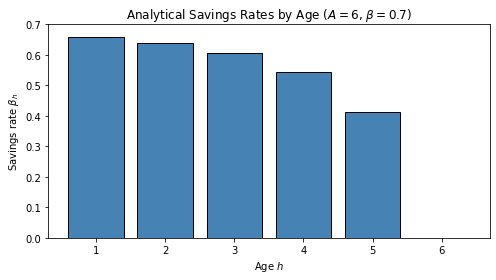


Young agents save the most because they have the longest remaining
horizon. The oldest agent saves nothing, since it dies next period.


In [4]:
A = 6
beta = 0.7

# Compute savings rates for each cohort h = 1, ..., A-1
savings_rates = []
for h in range(1, A):
    beta_h = beta * (1 - beta**(A - h)) / (1 - beta**(A - h + 1))
    savings_rates.append(beta_h)

# Agent A consumes everything (dies next period)
savings_rates.append(0.0)

# Print savings rates
for h, sr in enumerate(savings_rates, 1):
    print(f"  Agent h={h}: savings rate = {sr:.4f}")

# Bar chart
fig, ax = plt.subplots(figsize=(7, 4))
ages = np.arange(1, A + 1)
bars = ax.bar(ages, savings_rates, color='steelblue', edgecolor='black')
ax.set_xlabel('Age $h$')
ax.set_ylabel('Savings rate $\\beta_h$')
ax.set_title('Analytical Savings Rates by Age ($A=6$, $\\beta=0.7$)')
ax.set_xticks(ages)
ax.set_ylim(0, 0.7)
plt.tight_layout()
plt.show()

print("\nYoung agents save the most because they have the longest remaining")
print("horizon. The oldest agent saves nothing, since it dies next period.")

## Task 2a: Ergodic prices under the closed-form policy (8 min)

The savings rates are fractions; to turn them into a lifecycle you need prices, and prices depend on the capital stock that the savings rates themselves generate. So simulate.

With $A = 6$, only the young working ($\ell = (1,0,0,0,0,0)$), $\alpha = 0.3$, and the four i.i.d. shock states $(\eta, \delta) \in \{(0.95, 0.5), (1.05, 0.5), (0.95, 0.9), (1.05, 0.9)\}$, each with probability $1/4$, the prices in a period are

$$
  r = \alpha\,\eta\,K^{\alpha-1} + 1 - \delta, \qquad w = (1-\alpha)\,\eta\,K^{\alpha}, \qquad K = \sum_{h=1}^{A} k^h .
$$

Start from any positive capital distribution, and at every period: draw a shock, compute $K$, $r$, $w$; compute each cohort's cash-on-hand $\mathrm{inc}^h = r k^h + w\,\ell^h$; apply the savings rates, $a^h = \beta_h\,\mathrm{inc}^h$; and age everyone by one period (the newborn enters with $k^1 = 0$, so next period's holdings are $(0, a^1, \ldots, a^{A-1})$). Run 20,000 periods, discard the first 500, and report the **mean** of $r$, $w$ and $K$.

Before running it: do you expect the gross return $r$ to be above or below one?


In [5]:
alpha = 0.3
TFP = np.array([0.95, 1.05, 0.95, 1.05])
DEPR = np.array([0.50, 0.50, 0.90, 0.90])
labor = np.array([1.0, 0, 0, 0, 0, 0])
rates = np.array(savings_rates)          # beta_1..beta_5, 0  from Task 1
rng_sim = np.random.default_rng(0)

# TODO: simulate T = 20_000 periods, burn-in 500
# k = np.full(A, 0.1); k[0] = 0.0
# r_hist, w_hist, K_hist = [], [], []
# for t in range(T):
#     z = rng_sim.integers(4)
#     K = k.sum()
#     r = ...
#     w = ...
#     inc = r * k + w * labor
#     a = rates[:-1] * inc[:-1]          # cohorts 1..A-1 save; cohort A saves nothing
#     k = np.concatenate([[0.0], a])     # age everyone; newborn has no capital
#     if t >= 500: record r, w, K
#
# r_bar, w_bar, K_bar = ...
# print(f"ergodic-mean prices: r = {r_bar:.3f}, w = {w_bar:.3f}, K = {K_bar:.3f}")


### Solution

In [6]:
alpha = 0.3
TFP = np.array([0.95, 1.05, 0.95, 1.05])
DEPR = np.array([0.50, 0.50, 0.90, 0.90])
labor = np.array([1.0, 0, 0, 0, 0, 0])
rates = np.array(savings_rates)
rng_sim = np.random.default_rng(0)

T, burn_in = 20_000, 500
k = np.full(A, 0.1); k[0] = 0.0
r_hist, w_hist, K_hist = [], [], []
for t in range(T):
    z = rng_sim.integers(4)
    K = k.sum()
    r = alpha * TFP[z] * K ** (alpha - 1) + 1.0 - DEPR[z]
    w = (1 - alpha) * TFP[z] * K ** alpha
    inc = r * k + w * labor
    a = rates[:-1] * inc[:-1]
    k = np.concatenate([[0.0], a])
    if t >= burn_in:
        r_hist.append(r); w_hist.append(w); K_hist.append(K)

r_bar, w_bar, K_bar = np.mean(r_hist), np.mean(w_hist), np.mean(K_hist)
print(f"ergodic-mean prices: r = {r_bar:.3f}, w = {w_bar:.3f}, K = {K_bar:.3f}")
print(f"r ranges over [{np.min(r_hist):.3f}, {np.max(r_hist):.3f}] across shock states")

print("\nThe gross return is BELOW one: capital depreciates by 50% or 90% per period,")
print("so a unit saved returns less than a unit on average. The young save two thirds")
print("of their wage anyway - there is no other way to consume when old. Capital is")
print("held as a store of value at a negative net return.")


ergodic-mean prices: r = 0.687, w = 0.629, K = 0.707
r ranges over [0.400, 0.981] across shock states

The gross return is BELOW one: capital depreciates by 50% or 90% per period,
so a unit saved returns less than a unit on average. The young save two thirds
of their wage anyway - there is no other way to consume when old. Capital is
held as a store of value at a negative net return.


## Task 2b: Lifecycle of one cohort (5 min)

At the ergodic-mean prices from Task 2a, trace a single cohort from age 1 to age $A$:

- age 1 earns the wage $w$, saves $k_2 = \beta_1 w$, consumes $c_1 = (1-\beta_1)\,w$;
- age 2 earns $r k_2$, saves $k_3 = \beta_2\, r k_2$, consumes $c_2 = (1-\beta_2)\, r k_2$;
- … until age $A$ consumes everything.

Plot consumption and capital holdings against age. (Holding prices fixed at their means is an approximation, in the simulation they move with the shock, but it isolates the lifecycle shape.)


In [7]:
# Use r_bar and w_bar from Task 2a.

# TODO: simulate one lifecycle
# income = [w_bar]
# capital = []
# consumption = []
# for h in range(A):
#     c_h = (1 - savings_rates[h]) * income[h]
#     consumption.append(c_h)
#     if h < A - 1:
#         k_next = savings_rates[h] * income[h]
#         capital.append(k_next)
#         income.append(r_bar * k_next)

# TODO: plot consumption vs age and capital vs age (2 subplots)


### Solution

Lifecycle at ergodic-mean prices (r = 0.687, w = 0.629):
  Age 1: cash-on-hand = 0.6292, c = 0.2139, k_2 = 0.4153
  Age 2: cash-on-hand = 0.2853, c = 0.1029, k_3 = 0.1824
  Age 3: cash-on-hand = 0.1253, c = 0.0495, k_4 = 0.0758
  Age 4: cash-on-hand = 0.0521, c = 0.0238, k_5 = 0.0283
  Age 5: cash-on-hand = 0.0194, c = 0.0114, k_6 = 0.0080
  Age 6: cash-on-hand = 0.0055, c = 0.0055 (dies)


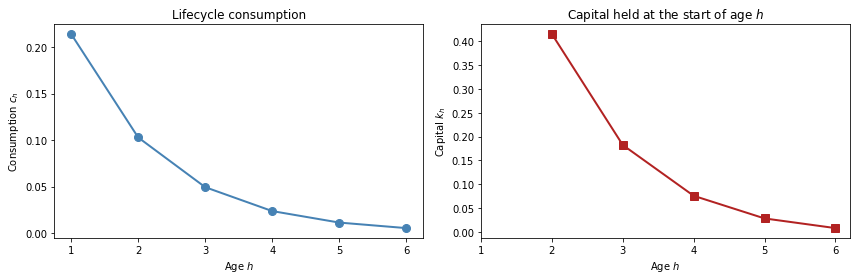


Consumption falls with age for two reasons that compound: the savings rate
declines as the horizon shortens, and each unit saved comes back as r < 1 units.
Only the newborn ever earns a wage, so there is no later income to smooth toward.


In [8]:
income = [w_bar]
capital = []
consumption = []
for h in range(A):
    c_h = (1 - savings_rates[h]) * income[h]
    consumption.append(c_h)
    if h < A - 1:
        k_next = savings_rates[h] * income[h]
        capital.append(k_next)
        income.append(r_bar * k_next)

print(f"Lifecycle at ergodic-mean prices (r = {r_bar:.3f}, w = {w_bar:.3f}):")
for h in range(A):
    cap_str = f", k_{h+2} = {capital[h]:.4f}" if h < A - 1 else " (dies)"
    print(f"  Age {h+1}: cash-on-hand = {income[h]:.4f}, c = {consumption[h]:.4f}{cap_str}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ages = np.arange(1, A + 1)
ax1.plot(ages, consumption, 'o-', color='steelblue', linewidth=2, markersize=8)
ax1.set_xlabel('Age $h$'); ax1.set_ylabel('Consumption $c_h$'); ax1.set_title('Lifecycle consumption'); ax1.set_xticks(ages)
ax2.plot(ages[1:], capital, 's-', color='firebrick', linewidth=2, markersize=8)
ax2.set_xlabel('Age $h$'); ax2.set_ylabel('Capital $k_h$'); ax2.set_title('Capital held at the start of age $h$'); ax2.set_xticks(ages)
plt.tight_layout()
plt.show()

print("\nConsumption falls with age for two reasons that compound: the savings rate")
print("declines as the horizon shortens, and each unit saved comes back as r < 1 units.")
print("Only the newborn ever earns a wage, so there is no later income to smooth toward.")


## Task 3: The discount factor, in general equilibrium (7 min)

Compare the lifecycle consumption profiles for $\beta \in \{0.5, 0.7, 0.9\}$. A different $\beta$ changes the savings rates, which changes the capital stock, which changes $r$ and $w$. So for each $\beta$, recompute the savings rates, **re-run the Task 2a simulation** to get that economy's ergodic-mean prices, and only then trace the lifecycle.

Plot the three consumption profiles on the same axes and print each economy's $(r, w, K)$. Which way does $r$ move as agents become more patient, and why?


In [9]:
beta_values = [0.5, 0.7, 0.9]

# TODO: for each beta_val:
#   1. savings rates sr = [beta_val (1-beta_val^(A-h)) / (1-beta_val^(A-h+1)) for h = 1..A-1] + [0]
#   2. simulate the economy (Task 2a) with these rates -> r_b, w_b, K_b
#   3. lifecycle at (r_b, w_b) (Task 2b) -> consumption profile
#   4. plot it, and print (beta_val, r_b, w_b, K_b)


### Solution

beta = 0.5: ergodic r = 0.838, w = 0.546, K = 0.438


beta = 0.7: ergodic r = 0.687, w = 0.629, K = 0.707


beta = 0.9: ergodic r = 0.615, w = 0.688, K = 0.952


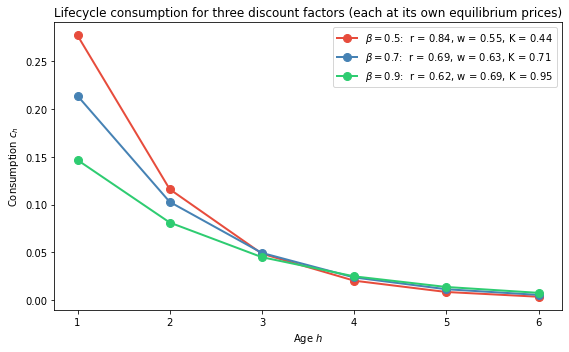


More patient agents save more, so the economy holds more capital. With
diminishing returns that LOWERS the gross return r and RAISES the wage w.
The patient economy therefore starts its lifecycle from a higher wage but
carries capital forward at a worse return - the profile is flatter, not because
consumption is smoothed toward later income (there is none), but because more
is put aside early and the cost of doing so has risen.


In [10]:
def savings_rates_for(beta_val):
    sr = [beta_val * (1 - beta_val ** (A - h)) / (1 - beta_val ** (A - h + 1)) for h in range(1, A)]
    return np.array(sr + [0.0])


def ergodic_prices(rates, T=20_000, burn_in=500, seed=0):
    rng_local = np.random.default_rng(seed)
    k = np.full(A, 0.1); k[0] = 0.0
    r_hist, w_hist, K_hist = [], [], []
    for t in range(T):
        z = rng_local.integers(4)
        K = k.sum()
        r = alpha * TFP[z] * K ** (alpha - 1) + 1.0 - DEPR[z]
        w = (1 - alpha) * TFP[z] * K ** alpha
        inc = r * k + w * labor
        k = np.concatenate([[0.0], rates[:-1] * inc[:-1]])
        if t >= burn_in:
            r_hist.append(r); w_hist.append(w); K_hist.append(K)
    return np.mean(r_hist), np.mean(w_hist), np.mean(K_hist)


def lifecycle(rates, r_, w_):
    inc, cons = [w_], []
    for h in range(A):
        cons.append((1 - rates[h]) * inc[h])
        if h < A - 1:
            inc.append(r_ * rates[h] * inc[h])
    return cons


colors = ['#e74c3c', 'steelblue', '#2ecc71']
fig, ax = plt.subplots(figsize=(8, 5))
for beta_val, color in zip(beta_values, colors):
    sr = savings_rates_for(beta_val)
    r_b, w_b, K_b = ergodic_prices(sr)
    cons = lifecycle(sr, r_b, w_b)
    ax.plot(range(1, A + 1), cons, 'o-', color=color, linewidth=2, markersize=8,
            label=f'$\\beta = {beta_val}$:  r = {r_b:.2f}, w = {w_b:.2f}, K = {K_b:.2f}')
    print(f"beta = {beta_val}: ergodic r = {r_b:.3f}, w = {w_b:.3f}, K = {K_b:.3f}")

ax.set_xlabel('Age $h$'); ax.set_ylabel('Consumption $c_h$')
ax.set_title('Lifecycle consumption for three discount factors (each at its own equilibrium prices)')
ax.set_xticks(range(1, A + 1)); ax.legend(); plt.tight_layout(); plt.show()

print("\nMore patient agents save more, so the economy holds more capital. With")
print("diminishing returns that LOWERS the gross return r and RAISES the wage w.")
print("The patient economy therefore starts its lifecycle from a higher wage but")
print("carries capital forward at a worse return - the profile is flatter, not because")
print("consumption is smoothed toward later income (there is none), but because more")
print("is put aside early and the cost of doing so has risen.")


## Summary

**Key takeaways:**

1. **Savings rates decline with age.** Young agents save a large fraction of cash-on-hand because they have many periods left over which to spread it; the oldest agent saves nothing. Returns do not enter; this is log utility.

2. **Prices are endogenous.** The savings rates determine the capital stock, and the capital stock determines $r$ and $w$. In this calibration the gross return is *below one*, depreciation of 50–90% per period sees to that, yet agents save anyway, because capital is the only store of value. A lifecycle profile has to use prices the model itself generates.

3. **The discount factor works through general equilibrium.** Higher $\beta$ raises saving, raises $K$, lowers $r$ and raises $w$. Comparing lifecycles at fixed prices would miss this.

4. **Connection to the DEQN.** `04_01_OLG_Analytic_DEQN_persistent.ipynb` trains a network to find these savings rates from the Euler equations alone, and prints the same ergodic prices along the closed-form path. The formulas above are the *exact* solution that the network approximates; comparing the two, cohort by cohort, is the validation step that makes this model the natural entry point.
